# Exploratorio del corpus | MIR Tarea 01

In [ ]:
import pandas as pd
import glob
import os

def merge_fma_data(dataset_type, base_path):
    """
    Carga, une y guarda los datos de FMA para un tipo de conjunto de datos (train o test).
    
    Args:
        dataset_type (str): El tipo de conjunto de datos, debe ser 'train' o 'test'.
        base_path (str): La ruta a la carpeta que contiene los archivos CSV.
    """
    print(f"Iniciando el proceso: {dataset_type.upper()}")
    
    try:
        # 1. Cargar los metadatos
        metadata_path = os.path.join(base_path, f'tracks_fma_{dataset_type}_metadata.csv')
        print(f"Cargando metadatos desde: {metadata_path}")
        df_merged = pd.read_csv(metadata_path)
        print(f"Metadatos cargados. Forma inicial: {df_merged.shape}")
        
        # 2. Encontrar todos los archivos de características (features)
        # El patrón busca cualquier archivo que coincida con la estructura de nombres
        features_pattern = os.path.join(base_path, f'tracks_fma_{dataset_type}_*_features.csv')
        feature_files = glob.glob(features_pattern)
        
        if not feature_files:
            print(f"ADVERTENCIA: No se encontraron archivos de características para '{dataset_type}' en la ruta especificada.")
            return

        print(f"Se encontraron {len(feature_files)} archivos de características.")
        
        # 3. Iterar y unir cada archivo de características
        for file_path in feature_files:
            file_name = os.path.basename(file_path)
            print(f"Uniendo: {file_name}...")
            
            df_feature = pd.read_csv(file_path)
            
            # Unir usando la columna 'track_id'
            df_merged = pd.merge(df_merged, df_feature, on='track_id', how='outer')

        # 4. Reportar y guardar el resultado
        print(f"\\nForma final del DataFrame '{dataset_type}': {df_merged.shape}")
        
        output_filename = f'fma_{dataset_type}_merged.csv'
        output_path = os.path.join(base_path, output_filename) # Guardar en la misma carpeta
        
        df_merged.to_csv(output_path, index=False)
        
        print(f"Datos de '{dataset_type}' guardados en: {output_path}\\n")
        return df_merged

    except FileNotFoundError:
        print(f"ERROR: No se encontró el archivo de metadatos: {metadata_path}")
        print("Por favor, verifica que la ruta de la carpeta y los nombres de los archivos sean correctos.")
        return None

# IMPORTANTE: Reemplaza esta ruta con la tuya si es diferente.
# La '/' al final es importante.
file_directory = "/home/cesar/Descargas/MIR-features-tarea01/"

# Procesar el conjunto de entrenamiento
df_train = merge_fma_data('train', file_directory)

# Procesar el conjunto de prueba
df_test = merge_fma_data('test', file_directory)

# Opcional: Mostrar las primeras filas de los DataFrames si se crearon correctamente
if df_train is not None:
    print("\\nVista previa de los datos de TRAI unidos")
    display(df_train.head())
    
if df_test is not None:
    print("\\nVista previa de los datos de TEST unidos")
    display(df_test.head())

Iniciando el proceso: TRAIN
Cargando metadatos desde: /home/cesar/Descargas/MIR-features-tarea01/tracks_fma_train_metadata.csv
Metadatos cargados. Forma inicial: (12472, 5)
Se encontraron 10 archivos de características.
Uniendo: tracks_fma_train_social_features.csv...
Uniendo: tracks_fma_train_rmse_features.csv...
Uniendo: tracks_fma_train_tonnetz_features.csv...
Uniendo: tracks_fma_train_zcr_features.csv...
Uniendo: tracks_fma_train_chromacens_features.csv...
Uniendo: tracks_fma_train_spectral_features.csv...
Uniendo: tracks_fma_train_audio_features.csv...
Uniendo: tracks_fma_train_mfcc_features.csv...
Uniendo: tracks_fma_train_chromastft_features.csv...
Uniendo: tracks_fma_train_chromacqt_features.csv...
\nForma final del DataFrame 'train': (12472, 536)
Datos de 'train' guardados en: /home/cesar/Descargas/MIR-features-tarea01/fma_train_merged.csv\n
Iniciando el proceso: TEST
Cargando metadatos desde: /home/cesar/Descargas/MIR-features-tarea01/tracks_fma_test_metadata.csv
Metadatos ca

,track_id,file,album.title,artist.name,track.genre1,social_features.artist_discovery,social_features.artist_familiarity,social_features.artist_hotttnesss,social_features.song_currency,social_features.song_hotttnesss,...,chromacqt.std.03,chromacqt.std.04,chromacqt.std.05,chromacqt.std.06,chromacqt.std.07,chromacqt.std.08,chromacqt.std.09,chromacqt.std.10,chromacqt.std.11,chromacqt.std.12
0,2,fma_large/000/000002.mp3,AWOL - A Way Of Life,AWOL,Hip-Hop,0.388990,0.386740,0.406370,0.000000,0.000000,...,0.265110,0.236233,0.240283,0.266694,0.253122,0.235398,0.224825,0.232748,0.241133,0.204236
1,3,fma_large/000/000003.mp3,AWOL - A Way Of Life,AWOL,Hip-Hop,0.388990,0.386740,0.406370,0.000000,0.000000,...,0.254289,0.244836,0.211848,0.245807,0.209122,0.225268,0.203094,0.249586,0.248174,0.233538
2,5,fma_large/000/000005.mp3,AWOL - A Way Of Life,AWOL,Hip-Hop,0.388990,0.386740,0.406370,0.000000,0.000000,...,0.233674,0.233186,0.226433,0.238600,0.269667,0.305429,0.241888,0.242494,0.232426,0.242393
3,10,fma_large/000/000010.mp3,Constant Hitmaker,Kurt Vile,Pop,0.557339,0.614272,0.798387,0.005158,0.354516,...,0.172637,0.253625,0.190772,0.167853,0.186787,0.201067,0.268620,0.224365,0.196909,0.212375
4,134,fma_large/000/000134.mp3,AWOL - A Way Of Life,AWOL,Hip-Hop,0.388990,0.386740,0.406370,0.000000,0.000000,...,0.284263,0.245253,0.245566,0.270079,0.256636,0.301456,0.273452,0.283828,0.293366,0.253871


\nVista previa de los datos de TEST unidos


,track_id,file,album.title,artist.name,tonnetz.kurtosis.01,tonnetz.kurtosis.02,tonnetz.kurtosis.03,tonnetz.kurtosis.04,tonnetz.kurtosis.05,tonnetz.kurtosis.06,...,spectralcontrast.std.05,spectralcontrast.std.06,spectralcontrast.std.07,spectralrolloff.kurtosis.01,spectralrolloff.max.01,spectralrolloff.mean.01,spectralrolloff.median.01,spectralrolloff.min.01,spectralrolloff.skew.01,spectralrolloff.std.01
0,194,fma_large/000/000194.mp3,Blue Piano,Ed Askew,0.101040,0.378727,-0.169035,-1.118746,-0.891098,0.070102,...,3.988937,4.799113,5.215412,20.375896,9356.176758,1677.280151,1453.491211,0.0,4.104119,993.913086
1,196,fma_large/000/000196.mp3,What I Know,Ed Askew,8.266299,6.141022,0.031323,-1.282394,-1.275656,0.102420,...,5.227079,5.556888,4.118292,28.807117,10077.539062,1193.644898,915.161133,0.0,5.413999,1472.774414
2,198,fma_large/000/000198.mp3,Blue Piano,Ed Askew,0.304669,0.423369,-1.126441,-0.270392,-0.451874,-0.659094,...,3.686553,4.149623,4.645599,27.364910,10454.370117,1891.221313,1668.823242,0.0,4.423684,978.218933
3,206,fma_large/000/000206.mp3,What I Know,Ed Askew,0.374078,0.300485,-0.453109,-0.894339,-0.533660,-1.000757,...,6.016575,7.133446,1.549565,15.325034,10131.372070,1383.724487,958.227539,0.0,4.142745,1921.939575
4,207,fma_large/000/000207.mp3,Blue Piano,Ed Askew,0.459727,1.332353,-0.736655,-0.779795,-0.544242,0.033611,...,5.212338,5.733711,4.697860,6.292324,9711.474609,1389.602295,775.195312,0.0,2.712824,1803.012207


In [5]:
#revisemos las dimensiones de los datasets
print(f"Dimensiones del dataset de entrenamiento: {df_train.shape}")
print(f"Dimensiones del dataset de prueba: {df_test.shape}")

Dimensiones del dataset de entrenamiento: (12472, 536)
Dimensiones del dataset de prueba: (657, 535)


In [ ]:
# veamos qué columnas no están en el dataset de prueba, pero sí en el de entrenamiento
# Ya sabemos que test tiene una columna menos (queremos que track.genere1 sea la etiqueta)
# entonces veamos si hicimos bien el merge


cols_train = set(df_train.columns)
cols_test = set(df_test.columns)
missing_in_test = cols_train - cols_test
print(f"Columnas en el dataset de entrenamiento pero no en el de prueba: {missing_in_test}")


Columnas en el dataset de entrenamiento pero no en el de prueba: {'track.genre1'}


In [9]:
# veamos ahora cuántos géneros únicos hay en el dataset de entrenamiento
unique_genres = df_train['track.genre1'].nunique()
print(f"Número de géneros únicos en el dataset de entrenamiento: {unique_genres}")



Número de géneros únicos en el dataset de entrenamiento: 15


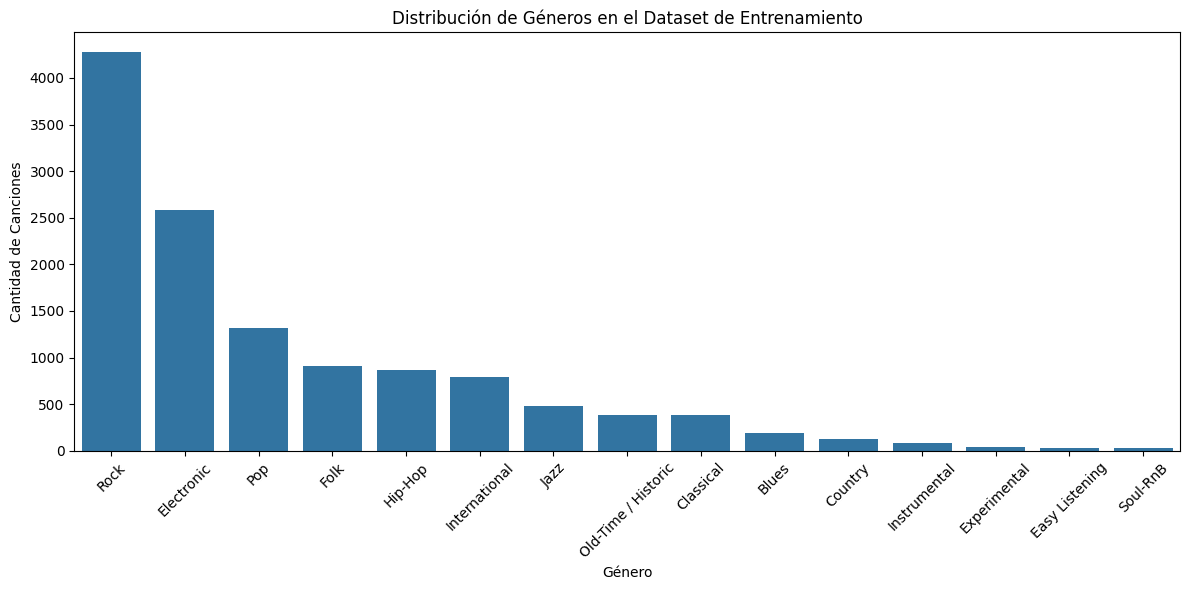

In [ ]:
# ahora vamos a ver con un bar plot la distribución de géneros en el dataset de entrenamiento

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.countplot(data=df_train, x='track.genre1', order=df_train['track.genre1'].value_counts().index)
plt.title('Distribución de Géneros en el Dataset de Entrenamiento')
plt.xlabel('Género')
plt.ylabel('Cantidad de Canciones')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()  

In [11]:
# vemos que hay un claro desbalance entre los géneros. El dominante es, por mucho, Rock.
# el siguiente paso será ver cómo podemos manejar este desbalance en el dataset.
# ahora, lo que haré será ver en qué proporción están los géneros en el dataset de entrenamiento.
genre_counts = df_train['track.genre1'].value_counts(normalize=True)
print("Proporción de géneros en el dataset de entrenamiento:")
print(genre_counts) 

Proporción de géneros en el dataset de entrenamiento:
track.genre1
Rock                   0.342768
Electronic             0.207184
Pop                    0.105276
Folk                   0.072963
Hip-Hop                0.069355
International          0.063182
Jazz                   0.038486
Old-Time / Historic    0.030789
Classical              0.030468
Blues                  0.015635
Country                0.009862
Instrumental           0.006414
Experimental           0.003287
Easy Listening         0.002245
Soul-RnB               0.002085
Name: proportion, dtype: float64


#### Podemos notar que hay un claro desbalance entre los géneros. El dominante es, por mucho, Rock. Antes del entrenamiento, deberemos de buscar una manera de manejar el desbalanceo de datos. 


El problema del desbalanceo de clases es uno de los más comunes al momento de trabajar con este tipo de problemas. Si no lo tratamos de alguna manera, lo más probable es que suceda un sesgo hacia la mayoría de nuestros datos, i.e. el género de "Rock" o incluso el de "Electronic", con un terrible desempeño en la clasificación de "Blues" o "Soul-RnB". A su vez, esto también podría provocar que tengamos un accuracy elevado gracisa al sesgo con los géneros sobrerepresentados. 

La primera idea que se me ocurrió fue la descartar géneros, por su súper baja representación. Sin embargo, creo que no es lo más adecuado pues queremos trabajar justo con ese tipo de problemas para intentar dar el mejor modleo posible. Podríamos realizar, quizás, un submuestro o undersamplig, pero tampoco creo que sea la mejor solución, vamos a tener que quedarnos con muy pocas muestras por género. 

SMOTE también podría ser una opción, pero no sé qué tan viable sea en este momento. A lo mejor una ponderación para las clases sea la mejor idea. También vamos a tener que tener cuidado con las métricas de validación, en general, nunca es conveniente quedarse solo con accuracy. Eso también lo plantearemos más a detalle después. 

#### Sigamos con el exploratorio

In [ ]:
columns_to_check = [
    'spectralcentroid.mean.01',
    'rmse.mean.01',
    'zcr.mean.01',
    'social_features.artist_hotttnesss',
    'track.genre1' 
]

print("🔎 Verificando la existencia de columnas en el DataFrame 'df_train'...")
print("-" * 50)

# Variable para saber si todas las columnas fueron encontradas
all_found = True

# Iteramos sobre la lista y revisamos cada columna
for col in columns_to_check:
    if col in df_train.columns:
        print(f"✔️  Columna encontrada: '{col}'")
    else:
        print(f"❌  ¡ALERTA! No se encontró la columna: '{col}'")
        all_found = False

print("-" * 50)

if all_found:
    print("✅ ¡Excelente! Todas las columnas clave están presentes. ¡Listo para explorar!")
else:
    print("⚠️ Revisa los nombres de las columnas no encontradas antes de continuar.")

🔎 Verificando la existencia de columnas en el DataFrame 'df_train'...
--------------------------------------------------
✔️  Columna encontrada: 'spectralcentroid.mean.01'
✔️  Columna encontrada: 'rmse.mean.01'
✔️  Columna encontrada: 'zcr.mean.01'
✔️  Columna encontrada: 'social_features.artist_hotttnesss'
✔️  Columna encontrada: 'track.genre1'
--------------------------------------------------
✅ ¡Excelente! Todas las columnas clave están presentes. ¡Listo para explorar!


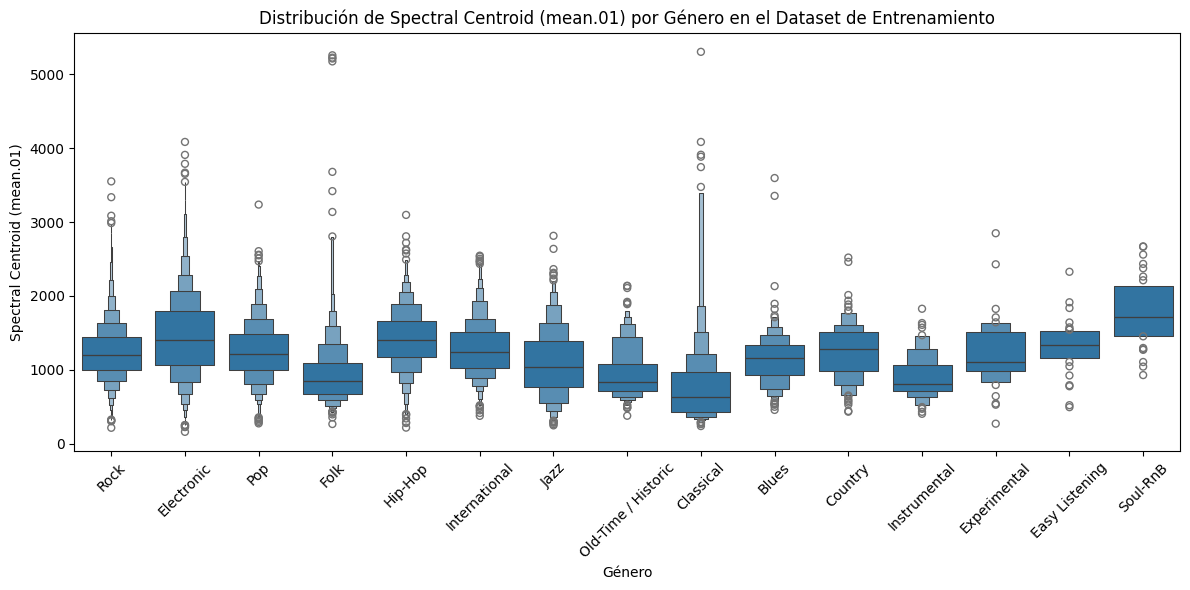

In [31]:
# Vamos a realizar la exploración con spectralcentroid.mean.01 en un violin plot
plt.figure(figsize=(12, 6))
sns.boxenplot(data=df_train, x='track.genre1', y='spectralcentroid.mean.01', order=df_train['track.genre1'].value_counts().index)
plt.title('Distribución de Spectral Centroid (mean.01) por Género en el Dataset de Entrenamiento')
plt.xlabel('Género')
plt.ylabel('Spectral Centroid (mean.01)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [33]:
# ahora veremos la tabla de medias de spectralcentroid.mean.01 por género ordenada de mayor a menor
spectral_means = df_train.groupby('track.genre1')['spectralcentroid.mean.01'].mean().reset_index()
spectral_means = spectral_means.rename(columns={'spectralcentroid.mean.01': 'Mean Spectral Centroid'})
spectral_means = spectral_means.sort_values(by='Mean Spectral Centroid', ascending=False)
print("Media de Spectral Centroid (mean.01) por Género:")
print(spectral_means)


Media de Spectral Centroid (mean.01) por Género:
           track.genre1  Mean Spectral Centroid
14             Soul-RnB             1766.345997
4            Electronic             1446.522405
7               Hip-Hop             1419.165888
3        Easy Listening             1310.350590
9         International             1281.468060
2               Country             1255.397247
12                  Pop             1248.243258
13                 Rock             1237.046262
5          Experimental             1227.950888
0                 Blues             1146.527127
10                 Jazz             1096.339781
6                  Folk              948.806078
11  Old-Time / Historic              948.559719
8          Instrumental              907.810315
1             Classical              792.782713


Spectral centroid mean intenta medir el timbre de una canción, i.e. si tiene una considerable presencia de agudos. Valores más bajos implican sonidos más graves. 

Algunos apuntes rápidos serían:

* Géneros con frecuencias más agudas: Soul-RnB, Electrónica y Hip-Hop. Esto tiene sentido si pensamos en que son géneros que suelen apoyarse mucho de sintetizadores y sonidos en general más límpios y electrónicos que otros géneros. 

* Géneros con frecuencias más graves: Clásica, Instrumental, Folk y Jazz. Al ser géneros con una presencvia más acústica, sus sonidos son un poco menos nítidos y más graves. 

* Valores intermedios muy poblados: parece que nuestro dataset contiene una especie de secuencia principal en la que los extremos están muy bien definidos, pero no creo que sea sencilla la clasificación de la secuencia principal, pues está muy poblada por el resto de los géneros que no habitan los extremos. 

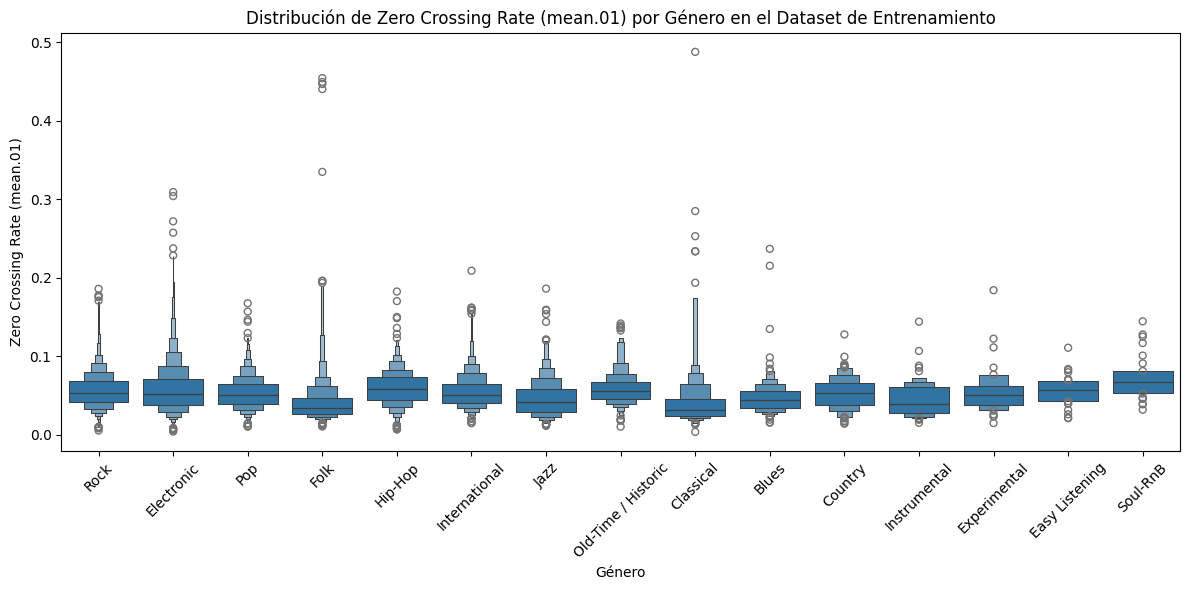

In [30]:
# ahora veremos la tasa de cruce por cero (zero crossing rate) por género 
# desplegaremos el violin plot y calcularemos la media de ZCR por género
plt.figure(figsize=(12, 6))
sns.boxenplot(data=df_train, x='track.genre1', y='zcr.mean.01', order=df_train['track.genre1'].value_counts().index)
plt.title('Distribución de Zero Crossing Rate (mean.01) por Género en el Dataset de Entrenamiento')
plt.xlabel('Género')
plt.ylabel('Zero Crossing Rate (mean.01)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()  

In [35]:
# ahora haremos la tabla de medias de ZCR por género ordenada de mayor a menor
zcr_means = df_train.groupby('track.genre1')['zcr.mean.01'].mean().reset_index()
zcr_means = zcr_means.rename(columns={'zcr.mean.01': 'Mean ZCR'})
zcr_means = zcr_means.sort_values(by='Mean ZCR', ascending=False)
print("Media de Zero Crossing Rate (mean.01) por Género:")
print(zcr_means)


Media de Zero Crossing Rate (mean.01) por Género:
           track.genre1  Mean ZCR
14             Soul-RnB  0.072248
7               Hip-Hop  0.059412
11  Old-Time / Historic  0.058743
4            Electronic  0.057536
13                 Rock  0.055970
3        Easy Listening  0.055816
5          Experimental  0.055398
9         International  0.054983
2               Country  0.053214
12                  Pop  0.053112
0                 Blues  0.047949
10                 Jazz  0.046295
8          Instrumental  0.044134
6                  Folk  0.042125
1             Classical  0.041235


Un ZCR (Tasa de Cruce por Cero), se asocia a sonidos percusivos, como lo son golpes de batería o un aguitarra distorsionada, mientras que uno bajo está más asociado a sonidos tonales y sostenidos como un violín o una voz. Es decir, si lo pensamos como una señal, ZCR mide qué tan a menudo cierta señal cruza el eje horizontal bajo un tiempo dado. Esta métrica nos dice cuando hay frecuecnias altas o incluso ruido en la señal. 

Dentro de nuestro corpus, podemos notar que Soul-RnB, Hip-Hop, Electrónica y Rock se presentan en la parte más alta de esta métrica. Como se mencionó anteriormente, los hi-hats y los snares de una batería o caja de ritmos provocan que la señal de audio cruce el eje de cero muy a menudo, incrementando los valores de ZCR. 

Además, notamos que Old-Time también tiene valores considerablemente altos. Esto es un poco extraño, pero no inesperado, ya que podría deberse a la calida dde la grabación y el ruido de fondo. 

Como era de esperarse, los géneros como Clásica, Folk, Instrumental y Jazz están hasta abajo de la lista, presentanod menos vlaor de ZCR. Esto puede deberse a que su sonido es predominantemente dominado por instrumentos que producen notas más claras y menos violentas, como lo son instrumentos de cuerdas, viento o guitarras acústicas sin distorción. 

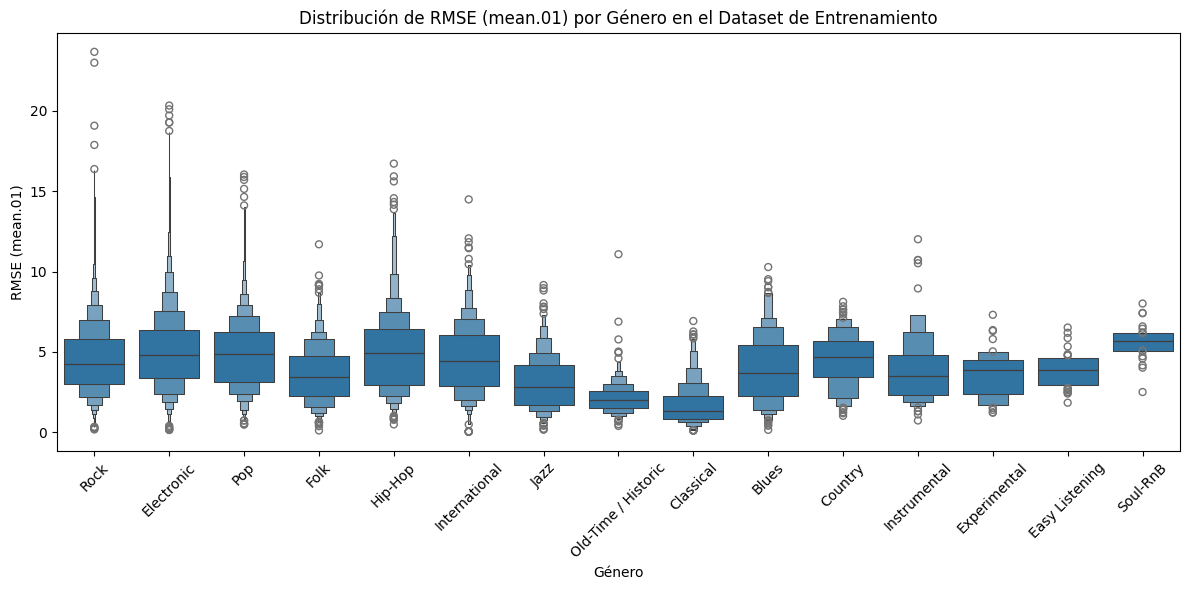

In [41]:
# violin plot del rsme.mean.01 por género
plt.figure(figsize=(12, 6))
sns.boxenplot(data=df_train, x='track.genre1', y='rmse.mean.01', order=df_train['track.genre1'].value_counts().index)
plt.title('Distribución de RMSE (mean.01) por Género en el Dataset de Entrenamiento')
plt.xlabel('Género')
plt.ylabel('RMSE (mean.01)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [40]:
# podemos hacer una tabla de valores medios de rmse.mean.01 por género ordenada de mayor a menor
rmse_means = df_train.groupby('track.genre1')['rmse.mean.01'].mean().reset_index()
rmse_means = rmse_means.rename(columns={'rmse.mean.01': 'Mean RMSE'})
rmse_means = rmse_means.sort_values(by='Mean RMSE', ascending=False)
print("Media de RMSE (mean.01) por Género:")
print(rmse_means)   

Media de RMSE (mean.01) por Género:
           track.genre1  Mean RMSE
14             Soul-RnB   5.611330
4            Electronic   5.028152
7               Hip-Hop   4.953917
12                  Pop   4.865663
9         International   4.582238
2               Country   4.561634
13                 Rock   4.525105
0                 Blues   3.963563
8          Instrumental   3.943662
3        Easy Listening   3.914864
6                  Folk   3.600615
5          Experimental   3.536763
10                 Jazz   3.052905
11  Old-Time / Historic   2.137199
1             Classical   1.704415


La energía promedio o RMSE mide la intensidad o potencia promedio de una señal a lo largo del tiempo. En lugar de un simple promedio, el RMSE proporciona un valor más representativo de la energía real de la señal, lo que se correlaciona mejor con cómo percibimos la sonoridad o la fuerza de un fenómeno.

Valores altos de RMSE indican que una señal carga mayor energía o intensidad promedio. Valores más bajos indican una señal menos intensa. Un audio con RMSE alto se percibirá como conun volumen más alto, mientras que uno con un valor bajo sería una cacnión con menor volúmen. 

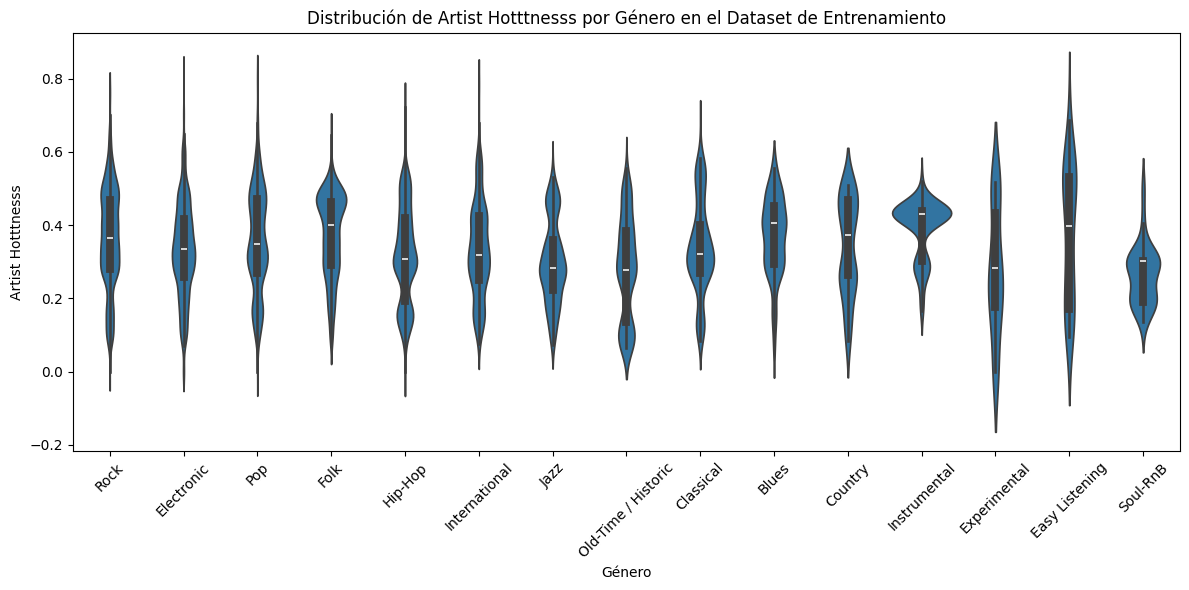

In [25]:
# veamos ahora un violin plot para social_features.artist_hotttnesss
plt.figure(figsize=(12, 6))
sns.violinplot(data=df_train, x='track.genre1', y='social_features.artist_hotttnesss', order=df_train['track.genre1'].value_counts().index)
plt.title('Distribución de Artist Hotttnesss por Género en el Dataset de Entrenamiento')
plt.xlabel('Género')
plt.ylabel('Artist Hotttnesss')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [37]:
# visualizamos la media de artist_hotttnesss por género ordenada de mayor a menor
artist_means = df_train.groupby('track.genre1')['social_features.artist_hotttnesss'].mean().reset_index()
artist_means = artist_means.rename(columns={'social_features.artist_hotttnesss': 'Mean Artist Hotttnesss'})
artist_means = artist_means.sort_values(by='Mean Artist Hotttnesss', ascending=False)
print("Media de Artist Hotttnesss por Género:")
print(artist_means)

Media de Artist Hotttnesss por Género:
           track.genre1  Mean Artist Hotttnesss
8          Instrumental                0.391713
3        Easy Listening                0.377384
6                  Folk                0.371602
0                 Blues                0.369470
13                 Rock                0.365266
12                  Pop                0.358011
1             Classical                0.340412
2               Country                0.339093
4            Electronic                0.332205
9         International                0.331695
7               Hip-Hop                0.316841
10                 Jazz                0.300649
11  Old-Time / Historic                0.282261
5          Experimental                0.275585
14             Soul-RnB                0.264393


Artist Hotttnesss nos dice qué tan popular es el artista. En este caso, tenemos valores bastante cercanos entre ellos, aunque hay un cambio más significativo comparado con las otras métricas. Curiosamnete instrumental tiene a los artistas más populares en promedio. Soul-RnB a los menos populares. Podría ser una métrica interesante para la clasificación. 